# 12 · Clustering — K-Means, DBSCAN & Hierarchical

**Difficulty:** Intermediate | **Time:** ~2.5 hours

Clustering = **Unsupervised Learning** — finding hidden groups in data with no labels.

## Table of Contents
1. What is Clustering?
2. K-Means Clustering
3. Choosing K — Elbow & Silhouette
4. DBSCAN — Density-Based Clustering
5. Hierarchical Clustering & Dendrograms
6. Real-World: Customer Segmentation

## 1. When to Use Clustering?

- Customer segmentation (find groups of similar customers)
- Anomaly detection (outliers don't belong to any cluster)
- Image compression (group similar pixel colors)
- Document grouping (group similar articles)
- Genomics (group similar genes)

**Key difference from classification:** No labels provided — the algorithm discovers structure on its own.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs, make_moons
import warnings
warnings.filterwarnings('ignore')
print("Ready ✓")

Ready ✓


## 2. K-Means Clustering — How It Works

```
Step 1: Randomly place K centroids
Step 2: Assign each point to nearest centroid
Step 3: Move centroid to mean of its cluster
Step 4: Repeat steps 2-3 until no movement
```

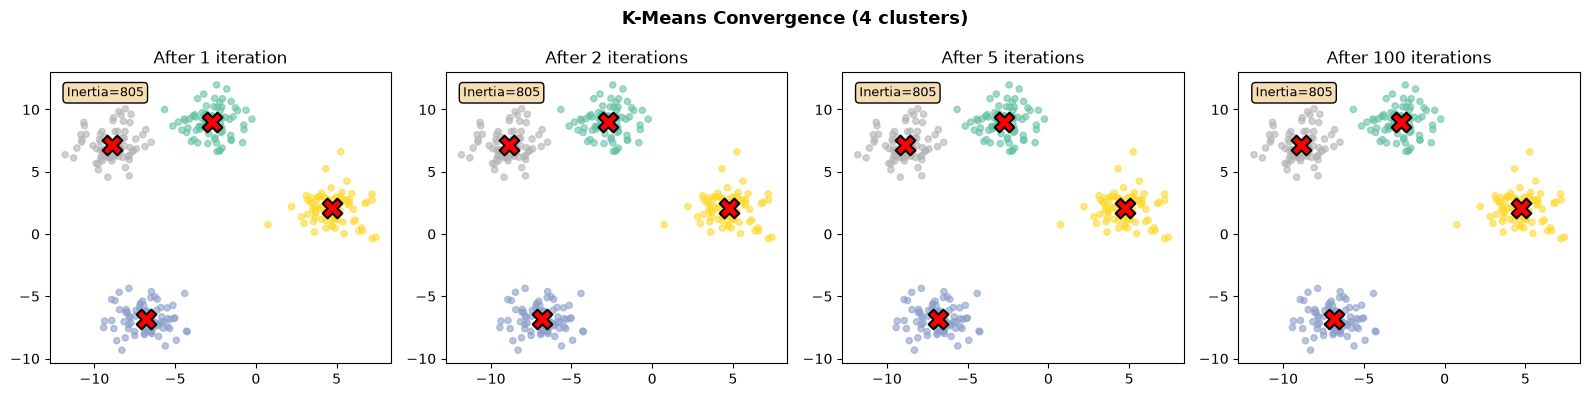

In [2]:
# Visualize K-Means convergence step by step
np.random.seed(42)
X_blobs, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)

# K-Means with different initializations to show random restart
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Animate convergence
for step, max_iter in enumerate([1, 2, 5, 100]):
    km = KMeans(n_clusters=4, max_iter=max_iter, n_init=1, random_state=42)
    km.fit(X_blobs)
    
    axes[step].scatter(X_blobs[:,0], X_blobs[:,1], c=km.labels_, cmap='Set2', s=20, alpha=0.6)
    axes[step].scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
                        c='red', marker='X', s=200, zorder=5, linewidths=1.5,
                        edgecolors='black')
    axes[step].set_title(f"After {max_iter} iteration{'s' if max_iter>1 else ''}")
    inertia = km.inertia_
    axes[step].text(0.05, 0.95, f'Inertia={inertia:.0f}', transform=axes[step].transAxes,
                    fontsize=9, va='top', bbox=dict(boxstyle='round', facecolor='wheat'))

plt.suptitle("K-Means Convergence (4 clusters)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/kmeans_convergence.png", dpi=100)
plt.show()

## 3. Choosing K — Elbow Method & Silhouette Score

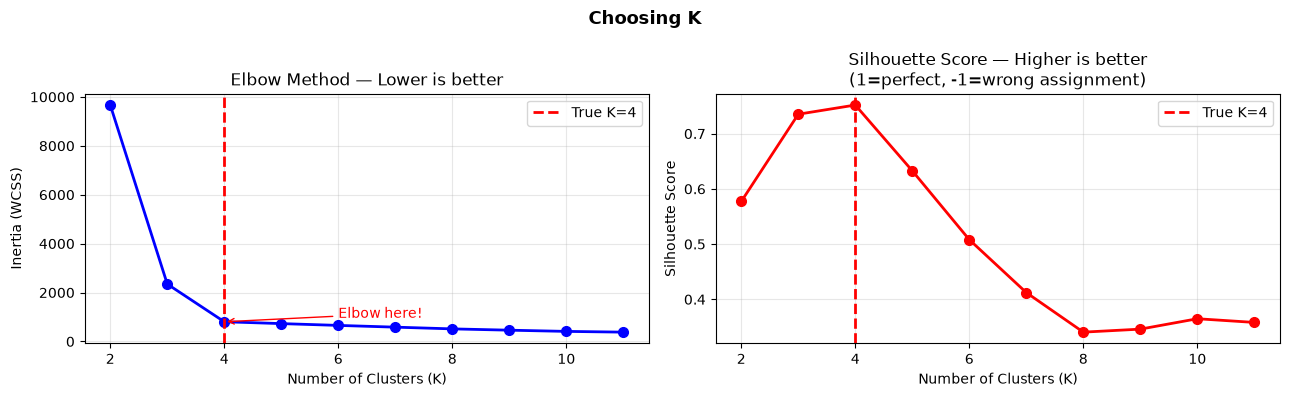

Best K by silhouette: 4


In [3]:
# Elbow Method: plot inertia vs K
inertias, silhouettes = [], []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blobs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_blobs, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
axes[0].plot(K_range, inertias, 'b-o', ms=7, linewidth=2)
axes[0].axvline(4, color='red', linestyle='--', linewidth=2, label='True K=4')
axes[0].set_xlabel("Number of Clusters (K)"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method — Lower is better")
axes[0].legend(); axes[0].grid(alpha=0.3)
# Annotate elbow
axes[0].annotate('Elbow here!', xy=(4, inertias[2]),
                  xytext=(6, inertias[2]*1.2), fontsize=10, color='red',
                  arrowprops=dict(arrowstyle='->', color='red'))

# Silhouette
axes[1].plot(K_range, silhouettes, 'r-o', ms=7, linewidth=2)
axes[1].axvline(4, color='red', linestyle='--', linewidth=2, label='True K=4')
axes[1].set_xlabel("Number of Clusters (K)"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score — Higher is better\n(1=perfect, -1=wrong assignment)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Choosing K", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/kmeans_k_selection.png", dpi=100)
plt.show()
print(f"Best K by silhouette: {K_range[np.argmax(silhouettes)]}")

## 4. DBSCAN — Handles Arbitrary Shapes

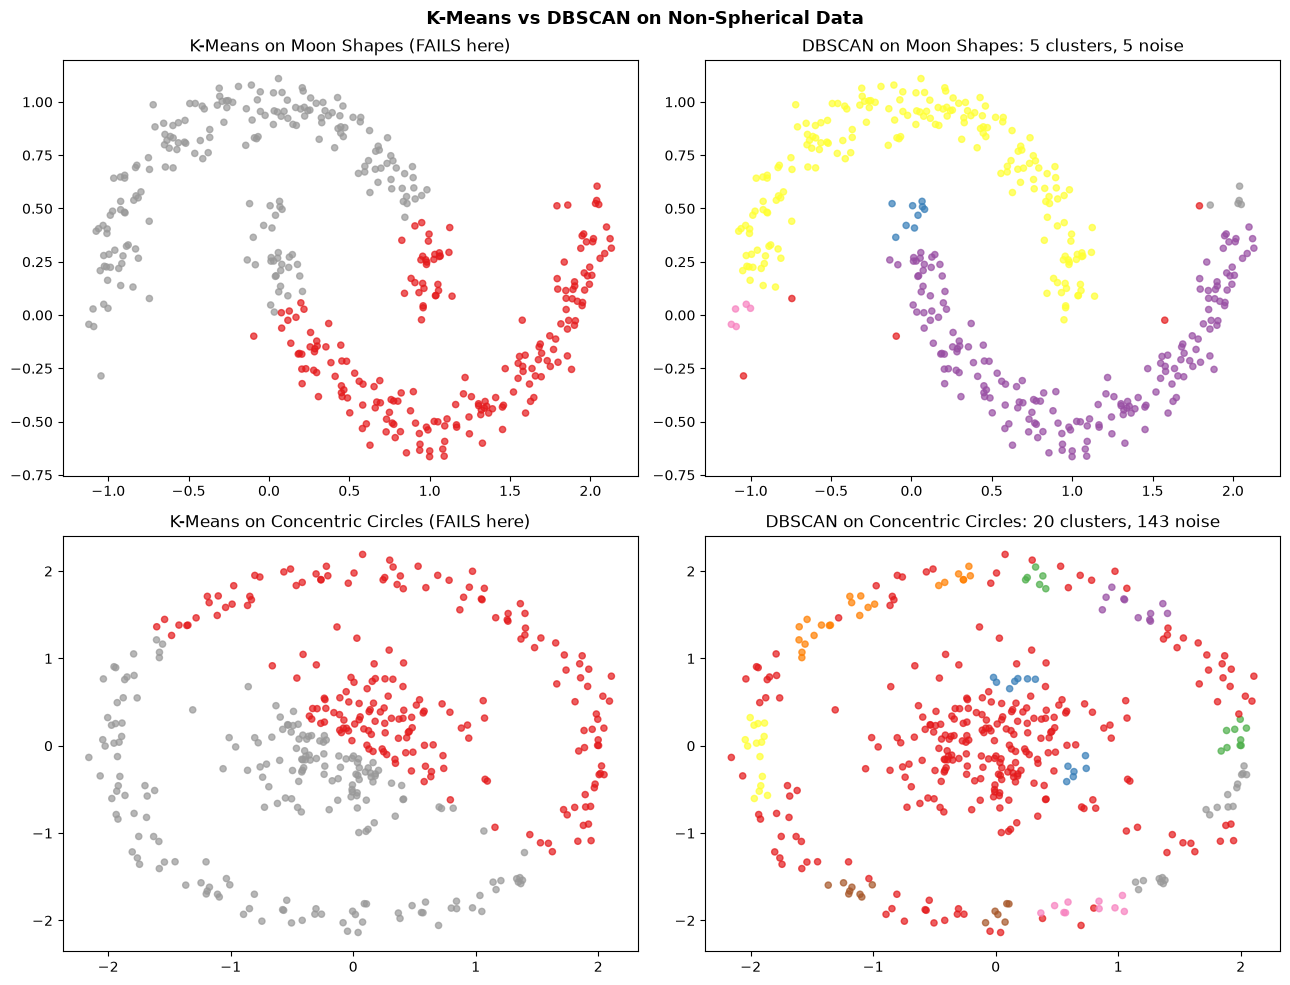

In [4]:
# DBSCAN works where K-Means fails: non-spherical clusters
X_moons, _ = make_moons(n_samples=400, noise=0.08, random_state=42)
X_circles = np.r_[
    np.random.randn(200, 2) * 0.5,
    2 * np.column_stack([np.cos(np.linspace(0, 2*np.pi, 200)),
                          np.sin(np.linspace(0, 2*np.pi, 200))])
    + np.random.randn(200, 2) * 0.1
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
datasets = [(X_moons, "Moon Shapes"), (X_circles, "Concentric Circles")]

for row, (X_d, title) in enumerate(datasets):
    sc = StandardScaler()
    X_ds = sc.fit_transform(X_d)
    
    # K-Means (fails)
    km = KMeans(n_clusters=2, random_state=42)
    km.fit(X_ds)
    axes[row, 0].scatter(X_d[:,0], X_d[:,1], c=km.labels_, cmap='Set1', s=20, alpha=0.7)
    axes[row, 0].set_title(f"K-Means on {title} (FAILS here)")
    
    # DBSCAN (wins)
    eps = 0.2 if row == 0 else 0.15
    db = DBSCAN(eps=eps, min_samples=5)
    db.fit(X_ds)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    axes[row, 1].scatter(X_d[:,0], X_d[:,1], c=labels, cmap='Set1', s=20, alpha=0.7)
    axes[row, 1].set_title(f"DBSCAN on {title}: {n_clusters} clusters, {n_noise} noise")

plt.suptitle("K-Means vs DBSCAN on Non-Spherical Data", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/dbscan.png", dpi=100)
plt.show()

In [5]:
print("DBSCAN Parameters:\n")
print("eps      : Maximum distance between two points to be neighbors")
print("           Too small → everything is noise")
print("           Too large → everything merges into one cluster")
print()
print("min_samples: Minimum points to form a dense region (core point)")
print()
print("Labels:")
print("  ≥ 0  : Cluster assignment (0, 1, 2, ...)")
print("  -1   : NOISE point (doesn't belong to any cluster)")
print()
print("DBSCAN is great for:")
print("  ✓ Arbitrary cluster shapes")
print("  ✓ Automatic noise detection (anomaly detection!)")
print("  ✗ High-dimensional data (distance becomes meaningless)")

DBSCAN Parameters:

eps      : Maximum distance between two points to be neighbors
           Too small → everything is noise
           Too large → everything merges into one cluster

min_samples: Minimum points to form a dense region (core point)

Labels:
  ≥ 0  : Cluster assignment (0, 1, 2, ...)
  -1   : NOISE point (doesn't belong to any cluster)

DBSCAN is great for:
  ✓ Arbitrary cluster shapes
  ✓ Automatic noise detection (anomaly detection!)
  ✗ High-dimensional data (distance becomes meaningless)


## 5. Hierarchical Clustering & Dendrogram

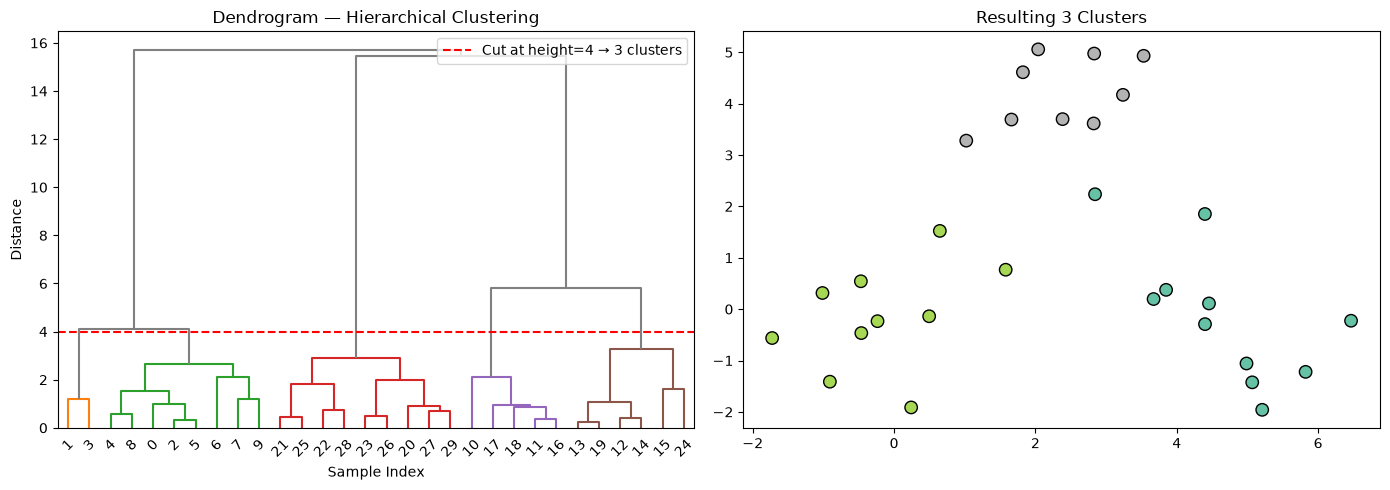

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Small dataset for clear visualization
np.random.seed(42)
X_hier = np.r_[
    np.random.randn(10, 2) + [0, 0],
    np.random.randn(10, 2) + [5, 0],
    np.random.randn(10, 2) + [2.5, 4]
]

linked = linkage(X_hier, method='ward')  # Ward: minimizes within-cluster variance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dendrogram
dg = dendrogram(linked, ax=axes[0], color_threshold=4,
                above_threshold_color='gray')
axes[0].axhline(4, color='red', linestyle='--', linewidth=1.5, label='Cut at height=4 → 3 clusters')
axes[0].set_title("Dendrogram — Hierarchical Clustering")
axes[0].set_xlabel("Sample Index"); axes[0].set_ylabel("Distance")
axes[0].legend()

# Cluster assignment
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_h = hc.fit_predict(X_hier)
axes[1].scatter(X_hier[:,0], X_hier[:,1], c=labels_h, cmap='Set2', s=80, edgecolors='black')
axes[1].set_title("Resulting 3 Clusters")

plt.tight_layout()
plt.savefig("/tmp/hierarchical.png", dpi=100)
plt.show()

## 6. Real-World: Customer Segmentation

In [7]:
# RFM Analysis — classic customer segmentation
# Recency (how recently), Frequency (how often), Monetary (how much)
np.random.seed(42)
n_cust = 500

customers = pd.DataFrame({
    'CustomerID' : range(1, n_cust+1),
    'Recency'    : np.random.exponential(30, n_cust).clip(1, 365).astype(int),  # days since last purchase
    'Frequency'  : np.random.exponential(10, n_cust).clip(1, 100).astype(int),  # purchases per year
    'Monetary'   : np.random.exponential(5000, n_cust).clip(100, 50000).astype(int)  # total spend
})

print("Customer RFM Dataset:")
print(customers.describe().round(1))

Customer RFM Dataset:
       CustomerID  Recency  Frequency  Monetary
count       500.0    500.0      500.0     500.0
mean        250.5     29.7        9.0    5402.1
std         144.5     29.2        9.6    5411.4
min           1.0      1.0        1.0     100.0
25%         125.8      8.0        2.0    1379.8
50%         250.5     21.0        6.0    3879.5
75%         375.2     42.0       12.2    7510.0
max         500.0    148.0       81.0   37208.0


In [8]:
# K-Means on RFM features
from sklearn.preprocessing import RobustScaler

X_rfm = customers[['Recency','Frequency','Monetary']].values
scaler_rfm = RobustScaler()
X_rfm_s = scaler_rfm.fit_transform(X_rfm)

# Find optimal K
sil_scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_rfm_s)
    sil_scores.append(silhouette_score(X_rfm_s, km.labels_))

best_k = np.argmax(sil_scores) + 2
print(f"Best K: {best_k} (Silhouette: {max(sil_scores):.3f})")

km_rfm = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customers['Segment'] = km_rfm.fit_predict(X_rfm_s)

Best K: 4 (Silhouette: 0.375)


Segment Profiles:
         Recency  Frequency  Monetary  Count
Segment                                     
0           23.9        6.3   14938.6     79
1           23.2       25.7    3936.4     80
2           83.0        7.3    4807.1     75
3           18.3        5.2    3178.4    266


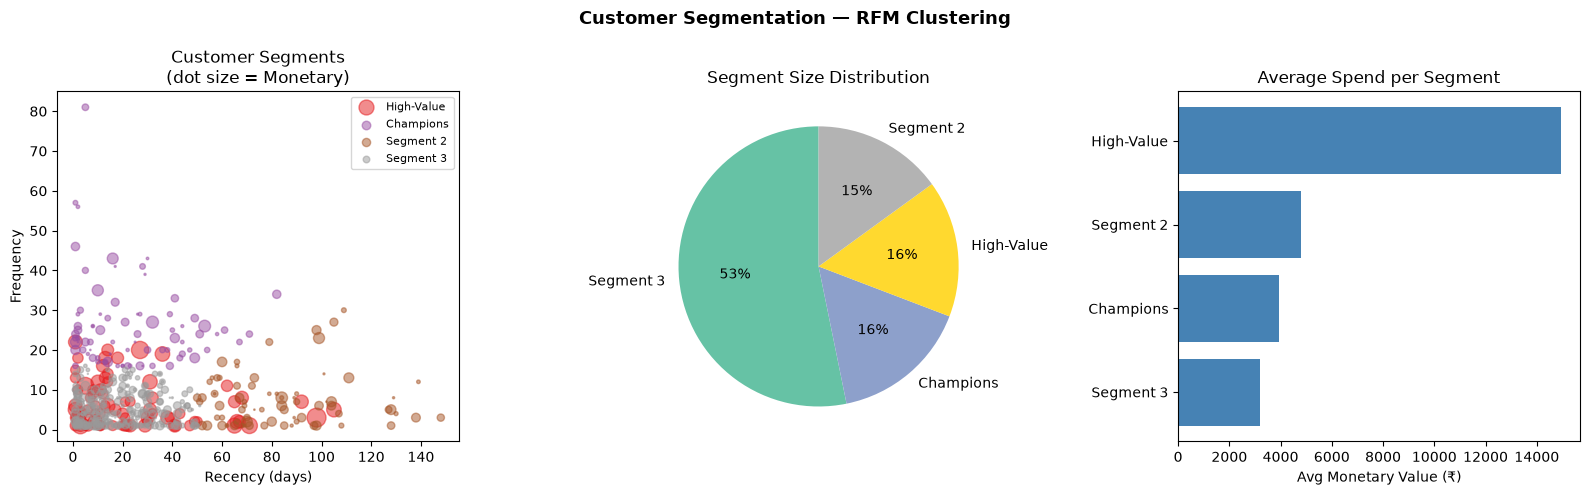

In [9]:
# Analyze and visualize segments
segment_profiles = customers.groupby('Segment').agg({
    'Recency'  : 'mean',
    'Frequency': 'mean',
    'Monetary' : 'mean',
    'CustomerID': 'count'
}).round(1).rename(columns={'CustomerID':'Count'})

# Assign meaningful names
segment_names = {}
for seg in range(best_k):
    row = segment_profiles.loc[seg]
    if row['Recency'] < 30 and row['Frequency'] > 15:
        segment_names[seg] = "Champions"
    elif row['Monetary'] > 8000:
        segment_names[seg] = "High-Value"
    elif row['Recency'] > 100:
        segment_names[seg] = "At Risk"
    else:
        segment_names[seg] = f"Segment {seg}"

customers['Segment_Name'] = customers['Segment'].map(segment_names)
print("Segment Profiles:")
print(segment_profiles)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 3D-style scatter (Recency vs Frequency, size=Monetary)
seg_colors = plt.cm.Set1(np.linspace(0, 1, best_k))
for seg in range(best_k):
    mask = customers['Segment'] == seg
    axes[0].scatter(customers.loc[mask,'Recency'],
                    customers.loc[mask,'Frequency'],
                    s=customers.loc[mask,'Monetary']/200,
                    alpha=0.5, color=seg_colors[seg],
                    label=segment_names[seg])
axes[0].set_xlabel("Recency (days)"); axes[0].set_ylabel("Frequency")
axes[0].set_title("Customer Segments\n(dot size = Monetary)")
axes[0].legend(fontsize=8)

# Segment size
seg_counts = customers['Segment_Name'].value_counts()
axes[1].pie(seg_counts, labels=seg_counts.index, autopct='%1.0f%%',
            colors=plt.cm.Set2(np.linspace(0, 1, len(seg_counts))), startangle=90)
axes[1].set_title("Segment Size Distribution")

# Average Monetary per segment
seg_money = customers.groupby('Segment_Name')['Monetary'].mean().sort_values(ascending=True)
axes[2].barh(seg_money.index, seg_money, color='steelblue')
axes[2].set_title("Average Spend per Segment")
axes[2].set_xlabel("Avg Monetary Value (₹)")

plt.suptitle("Customer Segmentation — RFM Clustering", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/customer_segments.png", dpi=100)
plt.show()

## Summary

| Algorithm | Best For | Not Good For |
|---|---|---|
| K-Means | Spherical clusters, large data | Non-spherical, outliers |
| DBSCAN | Arbitrary shapes, anomaly detection | High dimensions |
| Hierarchical | Knowing the hierarchy, small data | Large datasets |

**Next notebook →** `13_Dimensionality_Reduction_PCA.ipynb`